In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [264]:
# Step 1: Load Data (Replace with actual dataset)
df = pd.read_csv("restaurants_dataset_cleaned2.csv") 

# Data Pre-processing

In [267]:
# Step 2: Preprocess Data

# Fill missing values (if any)
df.fillna(0, inplace=True)

# Convert categorical columns using One-Hot Encoding (if needed)
#df = pd.get_dummies(df, columns=['Category'], drop_first=True)

df['Coordinates'] = list(zip(df['POI Latitude'], df['POI Longitude']))
print(df[['Coordinates']])


                 Coordinates
0     (26.430551, 50.133611)
1     (26.415718, 50.116699)
2     (26.403173, 50.159621)
3     (26.415625, 50.116605)
4     (26.415074, 50.170322)
5      (26.415157, 50.15032)
6     (26.416044, 50.172963)
7     (26.416041, 50.138379)
8     (26.418667, 50.161456)
9     (26.393853, 50.151787)
10     (26.41934, 50.128816)
11    (26.416508, 50.124358)
12    (26.419013, 50.123047)
13    (26.388373, 50.144261)
14    (26.415074, 50.170322)
15     (26.41386, 50.120323)
16     (26.414306, 50.11991)
17     (26.41429, 50.119737)
18    (26.414152, 50.119596)
19    (26.414366, 50.118002)
20    (26.414289, 50.118081)
21    (26.402128, 50.118861)
22       (26.414, 50.174454)
23    (26.415256, 50.116465)
24    (26.415381, 50.116533)
25      (26.41581, 50.11632)
26    (26.401251, 50.114717)
27    (26.375968, 50.122288)
28     (26.400379, 50.11498)
29    (26.400157, 50.115595)
30    (26.371325, 50.139569)
31     (26.400356, 50.11501)
32    (26.400556, 50.114898)
33    (26.4002

In [ ]:
df

In [271]:
import numpy as np
from sklearn.cluster import DBSCAN

# Apply DBSCAN Clustering
dbscan = DBSCAN(eps=0.009, min_samples=3)  #eps was determined based on the 2nd derivative # eps defines the neighborhood size, min_samples defines cluster density
df['Cluster'] = dbscan.fit_predict(df[['POI Latitude', 'POI Longitude']])

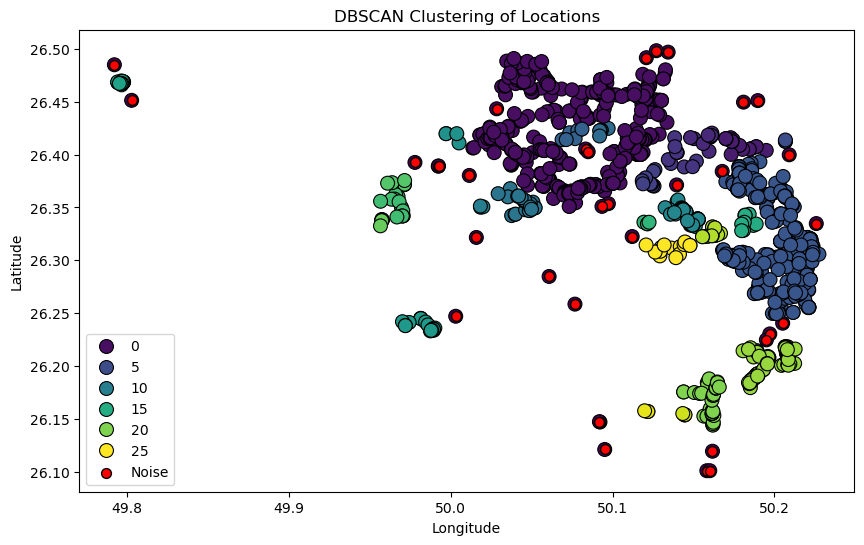

In [273]:
# Plot DBSCAN Clustering Results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['POI Longitude'], y=df['POI Latitude'], hue=df['Cluster'], palette='viridis', s=100, edgecolor='k')

# Highlight noise points (-1) separately
noise = df[df['Cluster'] == -1]
plt.scatter(noise['POI Longitude'], noise['POI Latitude'], color='red', label='Noise', s=50, edgecolors='black')

# Zoom in on a specific area (Adjust these values)

# Labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering of Locations")
plt.legend()
plt.show()

In [236]:
# Count the number of points in each cluster
cluster_counts = df['Cluster'].value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Number of Points']

# Display the count of neighbors per cluster
print(cluster_counts)

    Cluster  Number of Points
0         0               366
1         6               293
2        21                76
3        11                43
4        20                37
5        -1                34
6         9                24
7        14                21
8        22                18
9        13                17
10       25                17
11        1                16
12        4                14
13       17                12
14        2                10
15       15                10
16        3                 9
17        7                 7
18       18                 6
19       19                 6
20        8                 5
21       16                 4
22       23                 4
23       12                 4
24       10                 3
25        5                 3
26       24                 3


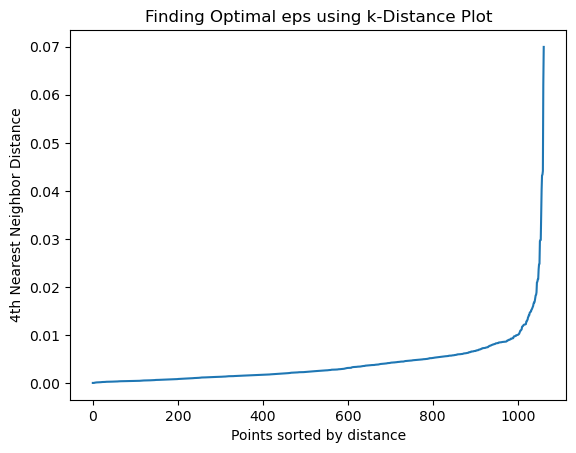

In [275]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Sample Data (Replace with your dataset)
X = df[['POI Latitude', 'POI Longitude']]

# Compute distances to the 4th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort and plot distances
distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("4th Nearest Neighbor Distance")
plt.title("Finding Optimal eps using k-Distance Plot")
plt.show()


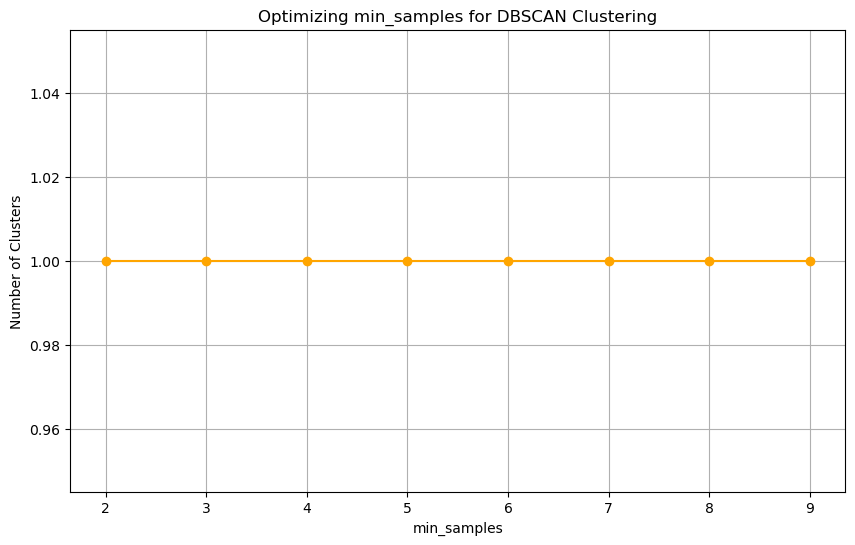

Optimal min_samples value: 2


In [277]:

k_distances = distances

# Compute the second derivative (to find the elbow point)
second_derivative = np.gradient(np.gradient(k_distances))

# Find the elbow point (where curvature changes the most)
elbow_index = np.argmax(second_derivative)  # The highest curvature change
optimal_eps = k_distances[elbow_index]  # Extract optimal eps from k-distances

# Define a range of min_samples values to test
min_samples_range = range(2, 10)  # Testing values from 2 to 10

# Store the number of clusters for each min_samples value
cluster_counts = []

for min_samples in min_samples_range:
    # Apply DBSCAN with different min_samples values
    dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples)
    cluster_labels = dbscan.fit_predict(k_distances.reshape(-1, 1))  # Reshaping for 1D input
    
    # Count the number of unique clusters (excluding noise -1)
    num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    cluster_counts.append(num_clusters)

# Plot the effect of min_samples on the number of clusters
plt.figure(figsize=(10, 6))
plt.plot(min_samples_range, cluster_counts, marker='o', linestyle='-', color='orange')
plt.xlabel("min_samples")
plt.ylabel("Number of Clusters")
plt.title("Optimizing min_samples for DBSCAN Clustering")
plt.xticks(min_samples_range)
plt.grid(True)
plt.show()

# ✅ Determine the optimal min_samples where the number of clusters stabilizes
optimal_min_samples = min_samples_range[np.argmax(cluster_counts)]

# ✅ Print the optimal min_samples value
print(f"Optimal min_samples value: {optimal_min_samples}")

In [279]:
import folium
from folium.plugins import MarkerCluster
from sklearn.cluster import DBSCAN


# Create a Folium Map Centered Around the Mean Location
map_center = [df['POI Latitude'].mean(), df['POI Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=12)

# Add a Marker Cluster Layer
marker_cluster = MarkerCluster().add_to(m)

# Define Colors for Clusters
cluster_colors = ['blue', 'green', 'purple', 'orange', 'darkred', 'cadetblue', 'lightgray', 'pink']

# Add Markers for Each Location
for _, row in df.iterrows():
    cluster_label = row['Cluster']
    
    # Assign color based on cluster (black for noise)
    color = 'black' if cluster_label == -1 else cluster_colors[cluster_label % len(cluster_colors)]
    
    # Add marker to the cluster layer
    folium.Marker(
        location=[row['POI Latitude'], row['POI Longitude']],
        popup=f"Cluster: {cluster_label} POI: {row['POI Name']}",
        icon=folium.Icon(color=color)
    ).add_to(marker_cluster)

# Display the Interactive Map
m

In [281]:
# ✅ Create a Base Map Centered Around the Mean Location
map_center = [df['POI Latitude'].mean(), df['POI Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=5)

# ✅ Add Markers for Each Location
for _, row in df.iterrows():
    folium.Marker(
        location=[row['POI Latitude'], row['POI Longitude']],
        popup=f"Location: {row['POI Latitude']}, {row['POI Longitude']}",
        icon=folium.Icon(color="blue")
    ).add_to(m)

#Display
m

In [ ]:
df

In [291]:
#Determine Features
features_list = df.columns.tolist()

features_list.remove('Business ID')
features_list.remove('POI Name')
features_list.remove('Popularity')
features_list.remove('Category')
features_list.remove('POI Latitude')
features_list.remove('POI Longitude')
features_list.remove('Coordinates')


print(features_list)
df.info()
df.head()

['Rating', 'Cluster']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Business ID    1062 non-null   int64  
 1   POI Name       1062 non-null   object 
 2   POI Latitude   1062 non-null   float64
 3   POI Longitude  1062 non-null   float64
 4   Category       1062 non-null   object 
 5   Rating         1062 non-null   float64
 6   Popularity     1062 non-null   float64
 7   Coordinates    1062 non-null   object 
 8   Cluster        1062 non-null   int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 74.8+ KB


,Business ID,POI Name,POI Latitude,POI Longitude,Category,Rating,Popularity,Coordinates,Cluster
0,2,T.Fex (تي فكس),26.430551,50.133611,Comfort Food Restaurant,8.7,0.982019,"(26.430551, 50.133611)",0
1,8,هرفي,26.415718,50.116699,Fast Food Restaurant,7.9,0.984536,"(26.415718, 50.116699)",0
2,11,Al Saihati Restaurant,26.403173,50.159621,Diner,6.6,0.567463,"(26.403173, 50.159621)",2
3,12,Mishwar (مشوار),26.415625,50.116605,Middle Eastern Restaurant,6.9,0.958891,"(26.415625, 50.116605)",0
4,13,هرفي,26.415074,50.170322,Fast Food Restaurant,6.4,0.988690,"(26.415074, 50.170322)",1


In [293]:
#Step 3: Feature Selection
features = features_list
target = 'Popularity'  # Define popularity metric (customer visits)

#Step 4: Train-Test Split
X = df[features]
y = df[target]

#Train-test Ratio : 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest (RF)

## Model Construction

In [297]:
# Step 5: Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [299]:
# Step 6: Make Predictions
y_pred = rf_model.predict(X_test)


In [301]:
# Step 7: Evaluate Model Performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.2f}")


Root Mean Squared Error (RMSE): 0.201297
R² Score: 0.04


In [303]:
# Step 8: Feature Importance (Which factors affect popularity most?)
feature_importance = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

pd.set_option('display.max_rows', None)
print("\nFeature Importance:\n", feature_importance)


Feature Importance:
    Feature  Importance
0   Rating     0.67499
1  Cluster     0.32501


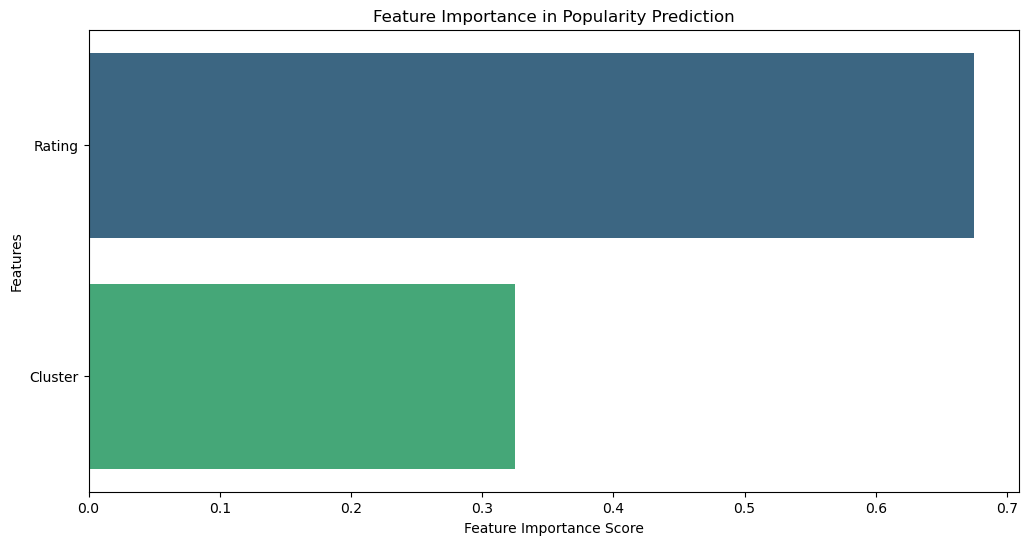

In [262]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', hue='Feature', dodge=False, legend=False, palette='viridis')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Popularity Prediction")
plt.show()

### With population data

In [26]:
business_data = pd.read_csv('updated_business_data_with_population_1km.csv')  

In [27]:
#Determine Features
features_list = business_data.columns.tolist()

features_list.remove('Business ID')
features_list.remove('POI Name')
features_list.remove('Popularity')
features_list.remove('Category')
features_list.remove('POI Latitude')
features_list.remove('POI Longitude')
features_list.remove('Matched Population')


print(features_list)
business_data.info()
business_data.head()

['Rating', 'Population Within 1km']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Business ID            1122 non-null   int64  
 1   POI Name               1122 non-null   object 
 2   POI Latitude           1122 non-null   float64
 3   POI Longitude          1122 non-null   float64
 4   Category               1122 non-null   object 
 5   Rating                 764 non-null    float64
 6   Popularity             1122 non-null   float64
 7   Matched Population     915 non-null    float64
 8   Population Within 1km  1122 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 79.0+ KB


,Business ID,POI Name,POI Latitude,POI Longitude,Category,Rating,Popularity,Matched Population,Population Within 1km
0,2,T.Fex (تي فكس),26.430551,50.133611,Comfort Food Restaurant,8.7,0.982019,NaN,9975
1,8,هرفي,26.415718,50.116699,Fast Food Restaurant,7.9,0.984536,1441.0,33274
2,11,Al Saihati Restaurant,26.403173,50.159621,Diner,6.6,0.567463,33.0,205
3,12,Mishwar (مشوار),26.415625,50.116605,Middle Eastern Restaurant,6.9,0.958891,1441.0,33274
4,13,هرفي,26.415074,50.170322,Fast Food Restaurant,6.4,0.988690,219.0,12554


In [29]:
#Step 3: Feature Selection
features = features_list
target = 'Popularity'  # Define popularity metric (customer visits)

#Step 4: Train-Test Split
X = business_data[features]
y = business_data[target]

#Train-test Ratio : 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:

# Step 5: Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
# Step 6: Make Predictions
y_pred = rf_model.predict(X_test)
# Step 7: Evaluate Model Performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.2f}")


Root Mean Squared Error (RMSE): 0.209210
R² Score: -0.08



Feature Importance:
                  Feature  Importance
1  Population Within 1km    0.689778
0                 Rating    0.310222


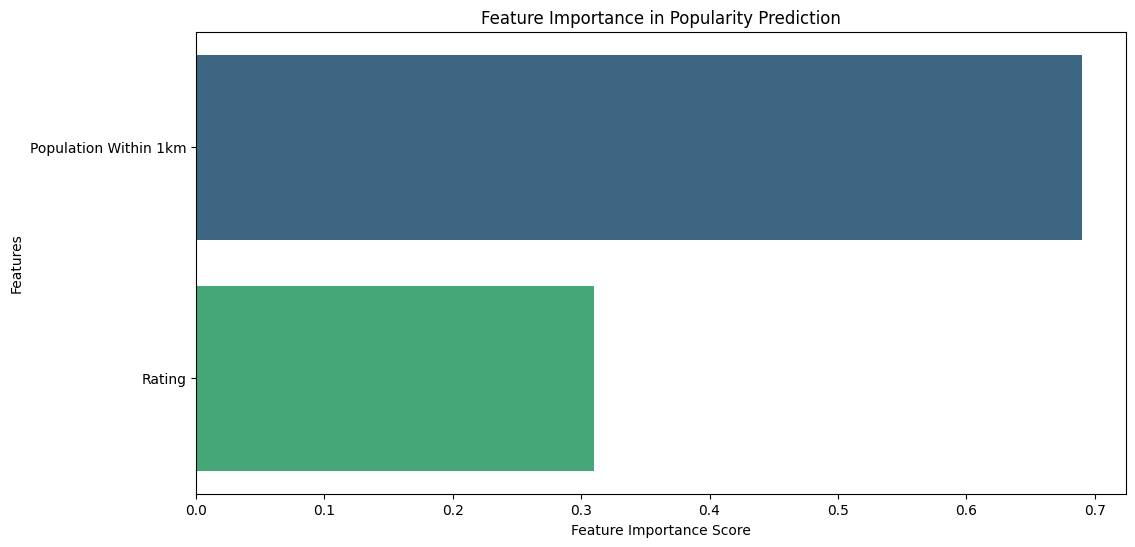

: 

In [31]:
# Step 8: Feature Importance (Which factors affect popularity most?)
feature_importance = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

pd.set_option('display.max_rows', None)
print("\nFeature Importance:\n", feature_importance)
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', hue='Feature', dodge=False, legend=False, palette='viridis')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Popularity Prediction")
plt.show()